In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
cd /content/drive/MyDrive/Colab/

/content/drive/MyDrive/Colab


In [3]:
!pip install eli5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for eli5: filename=eli5-0.13.0-py2.py3-none-any.whl size=107720 sha256=29e73152550ff4d372b5ae391885643100f3ce0fb61f97118278d411bc5b9195
  Stored in directory: /root/.cache/pip/wheels/b8/58/ef/2cf4c306898c2338d51540e0922c8e0d6028e07007085c0004
Successfully built eli5


In [4]:
from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
import plotly.graph_objects as go
from imblearn.combine import SMOTETomek
from eli5.sklearn import PermutationImportance
import eli5
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
from imblearn.under_sampling import *
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from xgboost import plot_importance
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import RobustScaler,StandardScaler,MinMaxScaler
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold, cross_val_score,cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings(action='ignore')
%matplotlib inline
from imblearn.under_sampling import TomekLinks,OneSidedSelection,RandomUnderSampler

In [5]:
def CVROC(model, X, y):
    cv = StratifiedKFold(n_splits = 5, shuffle=True,random_state = Ran_state)
    classifier = model

    prob = pd.DataFrame(columns=['LR','SVM','RF','XGB','GT'])

    for i, (train, test) in enumerate(cv.split(X, y)):
        LR = classifier[0].fit(X.iloc[train], y.iloc[train])
        RF = classifier[1].fit(X.iloc[train], y.iloc[train])
        XGB = classifier[2].fit(X.iloc[train], y.iloc[train])
        SVM = classifier[3].fit(X.iloc[train], y.iloc[train])
        lrproba = LR.predict_proba(X.iloc[test])[:, -1]
        rfproba = RF.predict_proba(X.iloc[test])[:, -1]
        xgbproba = XGB.predict_proba(X.iloc[test])[:, -1]
        svmproba = SVM.predict_proba(X.iloc[test])[:, -1]
        foldprob = pd.DataFrame(list(zip(lrproba, svmproba, rfproba, xgbproba, y.iloc[test].values)),
                                columns=['LR','SVM','RF','XGB','GT'])
       # prob = prob.append(foldprob)
        new_row = pd.DataFrame(foldprob)
        prob = pd.concat([prob, new_row], ignore_index=True)

    print(lrproba)
    print(prob)
    prob.to_csv("CVprob-mus.csv")
    lrfpr, lrtpr, _ = roc_curve(list(prob['GT']), list(prob['LR']))
    svmfpr, svmtpr, _ = roc_curve(list(prob['GT']), list(prob['SVM']))
    rffpr, rftpr, _ = roc_curve(list(prob['GT']), list(prob['RF']))
    xgbfpr, xgbtpr, _ = roc_curve(list(prob['GT']), list(prob['XGB']))
    lrauc = auc(lrfpr, lrtpr )
    svmauc = auc(svmfpr, svmtpr)
    rfauc = auc(rffpr, rftpr )
    xgbauc = auc(xgbfpr, xgbtpr)

    plt.figure(dpi=300, facecolor='white')
    rcParams['font.family'] = "Times New Roman"
    rcParams["legend.facecolor"] = 'white'
    rcParams["legend.edgecolor"] = 'white'
    plt.plot(lrfpr, lrtpr,  label="LR CV= %0.2f"  %(round(lrauc , 3)))
    plt.plot(svmfpr, svmtpr, label="SVM CV= %0.2f" %(round(svmauc, 3)))
    plt.plot(rffpr, rftpr,  label="RF CV= %0.2f"  %(round(rfauc , 3)))
    plt.plot(xgbfpr, xgbtpr, label="XGB CV= %0.2f" %(round(xgbauc, 3)))
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('1-specificity', fontsize=18)
    plt.ylabel('sensitivity', fontsize=18)
    plt.legend(loc="lower right", fontsize=12)
    plt.show()

In [6]:
Ran_state = 500

LR = LogisticRegression(C=115.72036673076951, random_state=1818)
RF = RandomForestClassifier(max_depth=171, min_samples_split=3, n_estimators=611,
                        random_state=1818)
XGB = XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
               colsample_bynode=1, colsample_bytree=1, eval_metric='auc',
               gamma=0, importance_type='gain',
               interaction_constraints='', learning_rate=0.009979787806885843,
               max_delta_step=0, max_depth=9, min_child_weight=1, missing=-999, n_estimators=425, n_jobs=88,
               num_parallel_tree=1, random_state=1818, reg_alpha=0, reg_lambda=1,
               scale_pos_weight=1, subsample=1, tree_method='exact',
               use_label_encoder=False, validate_parameters=1)
SVM = SVC(C=990.0511805421546, gamma=12.630867909389995, probability=True,
     random_state=1818)

classlist = [LR, RF, XGB, SVM]

In [7]:
df = pd.read_csv('data/Sarcopenia_Data.csv')
df = df.drop(['ID','Sarco1'], axis=1)
cv = StratifiedKFold(n_splits = 5, shuffle=True,random_state = Ran_state)

data_y = df['Sarco2']
data_x = df.drop(['Sarco2'],axis=1)

data_y.value_counts()

Sarco2
0    206
1     61
Name: count, dtype: int64

In [8]:
data_x

,Sex,10Percentile,90Percentile,Energy,Entropy,InterquartileRange,Kurtosis,Maximum,MeanAbsoluteDeviation,Mean,...,DependenceNonUniformityNormalized,DependenceVariance,HighGrayLevelEmphasis,LargeDependenceEmphasis,LargeDependenceHighGrayLevelEmphasis,LargeDependenceLowGrayLevelEmphasis,LowGrayLevelEmphasis,SmallDependenceEmphasis,SmallDependenceHighGrayLevelEmphasis,SmallDependenceLowGrayLevelEmphasis
0,0,89.0,140,899451843,1.754933,25,3.252866,200,15.305280,117.295912,...,0.092826,28.963051,10.984205,171.819778,1985.790341,17.980972,0.133775,0.019438,0.188188,0.005328
1,0,91.0,146,1073903169,1.694716,25,3.181552,200,16.280088,124.327107,...,0.104613,40.161993,12.925244,257.489411,3686.426368,21.247245,0.115842,0.013659,0.137397,0.003965
2,0,86.0,140,1075047768,1.804045,26,3.163111,200,16.215528,117.295542,...,0.091822,32.738440,11.043396,214.450347,2521.908989,22.921669,0.139249,0.014671,0.141265,0.004660
3,0,84.0,138,970142472,1.837435,30,2.898846,200,16.919144,114.523003,...,0.093088,31.359011,10.425207,201.449454,2249.125786,23.196051,0.147279,0.015611,0.137592,0.005088
4,1,92.0,138,1365346026,1.660936,21,3.540572,200,13.944330,118.723602,...,0.092203,30.689967,11.301211,200.502239,2385.714613,20.122074,0.122582,0.015288,0.160732,0.003580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,1,94.0,141,621543726,1.720988,21,3.628089,200,14.218079,120.363649,...,0.090118,31.233180,11.756660,172.730259,2108.565693,16.662671,0.119390,0.021364,0.228868,0.004717
263,0,86.0,136,595732164,1.744063,25,3.347679,200,15.391784,114.270698,...,0.086720,33.400653,10.242154,182.143624,2006.612509,19.846927,0.145595,0.020844,0.186647,0.006365
264,1,87.0,131,277883820,1.607744,23,3.799522,200,13.665604,111.760077,...,0.085433,37.143592,9.600911,196.898675,1969.901206,22.767435,0.146101,0.021106,0.176142,0.006177
265,0,85.0,130,415034154,1.632199,23,3.991854,200,13.911145,111.328801,...,0.087004,37.756192,9.294258,213.215036,2010.924820,26.422933,0.156755,0.018786,0.164460,0.005960


다중공선성 높은 변수들 제거

In [9]:
for i in range(len(data_x.columns)):
    vif = pd.DataFrame()
    vif["features"] = data_x.columns
    vif["VIF Factor"] = [variance_inflation_factor(
        data_x.values, i) for i in range(data_x.shape[1])]
    vif_remove = vif.sort_values(ascending=False, by='VIF Factor')[:]
    if vif_remove.iloc[0][1] > 10:
        data_x = data_x.drop([vif_remove.iloc[0][0]], axis=1)

In [10]:
vif = pd.DataFrame()
vif["features"] = data_x.columns
vif["VIF Factor"] = [variance_inflation_factor(
    data_x.values, i) for i in range(data_x.shape[1])]
vif_remove = vif.sort_values(ascending=False, by='VIF Factor')[:]
vif_remove

,features,VIF Factor
6,RunVariance,9.711613
1,Skewness,6.598305
3,ClusterShade,6.142303
4,LargeAreaHighGrayLevelEmphasis,4.588794
5,SizeZoneNonUniformity,4.372468
7,Coarseness,3.846364
0,Sex,3.248194
2,ClusterProminence,1.989599


In [11]:
MM = RobustScaler() #정규화
DFSMM = MM.fit_transform(data_x)
data_x = pd.DataFrame(DFSMM, columns=data_x.columns)

In [12]:
data_x, data_y = OneSidedSelection(random_state=Ran_state).fit_resample(data_x, data_y)
data_y.value_counts()

Sarco2
0    185
1     61
Name: count, dtype: int64

In [13]:
data_y.value_counts()

Sarco2
0    185
1     61
Name: count, dtype: int64

In [14]:
train_x, test_x, train_y, test_y = train_test_split(
    data_x, data_y, test_size=0.3, random_state=Ran_state,stratify=data_y)

==================================================================

학습 및 예측

In [15]:
def create_curve(classlist, train_x, train_y, test_x, test_y):
    MLP = classlist[0]
    RF = classlist[1]
    XGB = classlist[2]
    NB = classlist[3]

    MLP.fit(train_x, train_y)
    RF.fit(train_x, train_y)
    XGB.fit(train_x, train_y)
    NB.fit(train_x, train_y)



    print('==========================================')
    print(train_x.columns)
    print('==========================================')

    lr_pred = MLP.predict(test_x)
    rf_pred = RF.predict(test_x)
    xgb_pred = XGB.predict(test_x)
    svm_pred = NB.predict(test_x)

    print(rf_pred)

    MLP_proba = MLP.predict_proba(test_x)[:, 1]
    rf_proba = RF.predict_proba(test_x)[:, 1]
    xgb_proba = XGB.predict_proba(test_x)[:, 1]
    NB_proba = NB.predict_proba(test_x)[:, 1]
    proba = pd.DataFrame(list(zip(test_y, MLP_proba, NB_proba, rf_proba, xgb_proba)), columns=[
                         'GT', 'LR', 'SVM', 'RF', 'XGB'])
    proba.to_csv("prob-mus.csv")

    fpr_mlp, tpr_mlp, _ = roc_curve(test_y, MLP_proba)
    fpr_rf, tpr_rf, _ = roc_curve(test_y, rf_proba)
    fpr_xgb, tpr_xgb, _ = roc_curve(test_y, xgb_proba)
    fpr_nb, tpr_nb, _ = roc_curve(test_y, NB_proba)


    print('LR')
    tn, fp, fn, tp = confusion_matrix(test_y, lr_pred).ravel()
    print("tn = {} fp = {} fn = {} tp = {}".format(tn, fp, fn, tp))
    print('RF')
    tn, fp, fn, tp = confusion_matrix(test_y, rf_pred).ravel()
    print("tn = {} fp = {} fn = {} tp = {}".format(tn, fp, fn, tp))
    print('XGB')
    tn, fp, fn, tp = confusion_matrix(test_y, xgb_pred).ravel()
    print("tn = {} fp = {} fn = {} tp = {}".format(tn, fp, fn, tp))
    print('SVM')
    tn, fp, fn, tp = confusion_matrix(test_y, svm_pred).ravel()
    print("tn = {} fp = {} fn = {} tp = {}".format(tn, fp, fn, tp))

    auc_mlp = auc(fpr_mlp, tpr_mlp)
    auc_xgb = auc(fpr_xgb, tpr_xgb)
    auc_rf = auc(fpr_rf, tpr_rf)
    auc_nb = auc(fpr_nb, tpr_nb)

    rcParams['font.family'] = "Times New Roman"
    plt.figure(dpi=100, facecolor='white')
    plt.plot(fpr_mlp, tpr_mlp, label="LR (AUC= %s)" % (round(auc_mlp, 3)))
    plt.plot(fpr_nb, tpr_nb, label="SVM (AUC= %s)" % (round(auc_nb, 3)))
    plt.plot(fpr_rf, tpr_rf, label="RF (AUC= %s)" % (round(auc_rf, 3)))
    plt.plot(fpr_xgb, tpr_xgb, label="XGB (AUC= %s)" % (round(auc_xgb, 3)))
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('1-specificity', fontsize=18)
    plt.ylabel('sensitivity', fontsize=18)
    plt.legend(loc="lower right", fontsize=12)
    plt.show()

    Importance = pd.DataFrame(train_x.columns, columns=['feature'])
    suf = ('_LR', '_RF', '_XGB', '_SVM')

    for i in range(4):
        PI = P_Importance(classlist[i], test_x,
                          test_y).loc[:, ['feature', 'weight']]
        Importance = pd.merge(Importance, PI, on='feature',
                              suffixes=(suf[i-1], suf[i]))

    Importance['meanscore'] = Importance.apply(lambda x: np.mean(x[1:5]), 1)
    ftr_top20 = Importance.sort_values(ascending=False, by='meanscore')[:]

    fig = go.Figure([go.Bar(x=ftr_top20.meanscore, y=ftr_top20.feature, orientation='h', marker={
                    'color': ftr_top20.meanscore, 'colorscale': [[0, '#DDDDDD'], [1.0, 'black']]})])
    fig.update_layout(

        font=dict(
            family='Times New Roman',
            size=18
        ),
        autosize=False,
        width=900,
        height=600,
        #     xaxis=dict(type='category',tickfont_size=15),
        plot_bgcolor='rgba(0,0,0,0)'
    )
    fig.show()


    return Importance

In [16]:
def P_Importance(model, test_x, test_y):  # permutation importance 중요도 뽑기
    perm = PermutationImportance(
        model, scoring="roc_auc", random_state=Ran_state).fit(test_x, test_y)
    ftr_importances = eli5.format_as_dataframe(eli5.explain_weights(
        perm, top=255, feature_names=test_x.columns.tolist()))
    ftr_top = ftr_importances.sort_values(ascending=False, by='feature')[:]
    return ftr_top

Index(['Sex', 'Skewness', 'ClusterProminence', 'ClusterShade',
       'LargeAreaHighGrayLevelEmphasis', 'SizeZoneNonUniformity',
       'RunVariance', 'Coarseness'],
      dtype='object')
[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
LR
tn = 56 fp = 0 fn = 14 tp = 4
RF
tn = 56 fp = 0 fn = 13 tp = 5
XGB
tn = 53 fp = 3 fn = 7 tp = 11
SVM
tn = 56 fp = 0 fn = 18 tp = 0


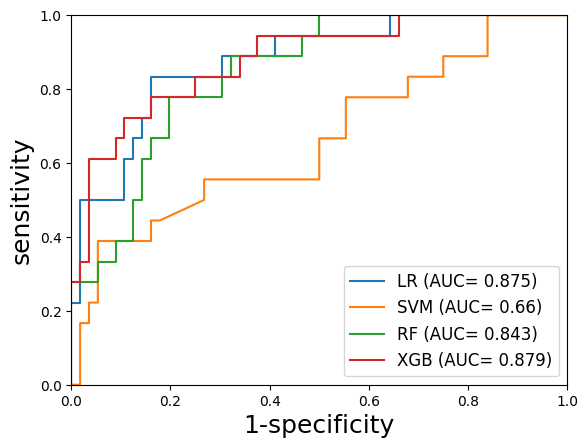

In [17]:
ftr_importances = create_curve(classlist, train_x, train_y, test_x, test_y)

In [18]:
data_x

,Sex,Skewness,ClusterProminence,ClusterShade,LargeAreaHighGrayLevelEmphasis,SizeZoneNonUniformity,RunVariance,Coarseness
0,-1.0,2.229847,0.545331,1.769662,-0.486062,-0.134671,0.242182,0.867551
1,-1.0,0.333122,0.347925,0.256762,-0.301021,0.638368,-0.827883,-0.176056
2,-1.0,0.231888,1.251056,-0.207466,0.327465,0.065416,0.092388,-0.131147
3,-1.0,0.708415,1.134880,0.576299,-0.079298,0.098768,-0.315313,-0.043676
4,0.0,-0.124549,-0.199391,-0.090607,0.268402,0.480424,-0.328964,-0.471589
...,...,...,...,...,...,...,...,...
241,0.0,0.237175,-0.171282,0.583654,-0.221374,-0.227816,0.057687,0.375225
242,0.0,0.004793,1.625975,-0.945045,-0.341945,1.946476,-0.848283,-0.060015
243,0.0,-0.002161,0.271879,-0.375993,-0.214121,0.027012,-0.465019,0.170404
244,0.0,-0.457954,-0.850980,0.245680,-0.166633,-1.187083,0.005035,0.815438


In [19]:
def myRFE(ftr_importances,train_x,train_y,classlist,num=5): #sequential feature selection
    ftr_bot = ftr_importances.sort_values(ascending=False, by='meanscore')
    for j in range(len(ftr_importances)-num):
        best_score = 0
        for i in range(len(train_x.columns)):
            CV_x = train_x.drop(ftr_bot.iloc[i][0],axis=1)
            mlpCV = np.mean(cross_val_score(classlist[0],CV_x,train_y,scoring='roc_auc',cv=cv))
            rfCV = np.mean(cross_val_score(classlist[1],CV_x,train_y,scoring='roc_auc',cv=cv))
            xgbCV = np.mean(cross_val_score(classlist[2],CV_x,train_y,scoring='roc_auc',cv=cv))
            nbCV = np.mean(cross_val_score(classlist[3],CV_x,train_y,scoring='roc_auc',cv=cv))
            Score = np.mean([mlpCV,rfCV,xgbCV,nbCV])
            if Score >= best_score:
                best_score = Score
                print("best_score = ", best_score)
                print("feature = ",ftr_bot.iloc[i][0])
                best_drop = i
        train_x = train_x.drop(ftr_bot.iloc[best_drop][0],axis=1)
        ftr_bot = ftr_bot[ftr_bot['feature']!=ftr_bot.iloc[best_drop][0]]
        print(train_x.columns)
    return train_x.columns

위에서 뽑은 importance 이용 Feature selection 과정

In [20]:
features = ['Sex', 'Skewness', 'ClusterProminence', 'Coarseness']
#features = myRFE(ftr_importances,train_x,train_y,classlist,num=4)
d_drop = data_x.drop(features, axis=1)
data_x = data_x.drop(d_drop.columns, axis=1)
train_x, test_x, train_y, test_y = train_test_split(data_x, data_y, test_size=0.3,stratify=data_y, random_state=Ran_state)
train_x, train_y = TomekLinks().fit_resample(train_x, train_y)

Index(['Sex', 'Skewness', 'ClusterProminence', 'Coarseness'], dtype='object')
[0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0
 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
LR
tn = 55 fp = 1 fn = 17 tp = 1
RF
tn = 52 fp = 4 fn = 11 tp = 7
XGB
tn = 49 fp = 7 fn = 9 tp = 9
SVM
tn = 52 fp = 4 fn = 11 tp = 7


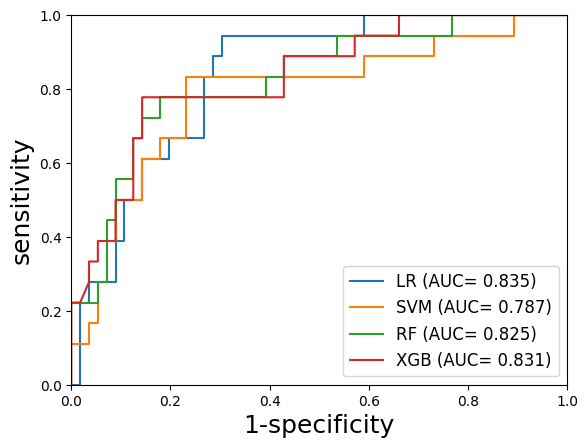

[0.03299764 0.05302287 0.36591727 0.32558963 0.04748649 0.0621192
 0.03899808 0.39054221 0.02457671 0.02625744 0.21591078 0.033282
 0.30549504 0.21016274 0.25428915 0.55233986 0.24075223 0.02649009
 0.02134713 0.43045751 0.01997912 0.03480819 0.05886975 0.02967093
 0.75969914 0.27187345 0.01910299 0.02310833 0.02618328 0.02102052
 0.28675265 0.34406592 0.021955   0.30223771 0.02373949 0.39330832
 0.03323259 0.74168934 0.25856554 0.55068168 0.31235933 0.42631093
 0.86001974 0.26911771 0.11197811 0.35331502 0.74814401 0.74442576
 0.37303482]
           LR       SVM        RF       XGB GT
0    0.022254  0.148172  0.043372  0.024642  0
1    0.418284  0.215410  0.612520  0.423192  0
2    0.305713  0.218134  0.016858  0.052667  0
3    0.255371  0.025451  0.083041  0.032907  0
4    0.047545  0.205510  0.182924  0.304427  0
..        ...       ...       ...       ... ..
241  0.111978  0.234843  0.109274  0.080134  1
242  0.353315  0.238451  0.739280  0.871430  1
243  0.748144  0.238341  0.5943

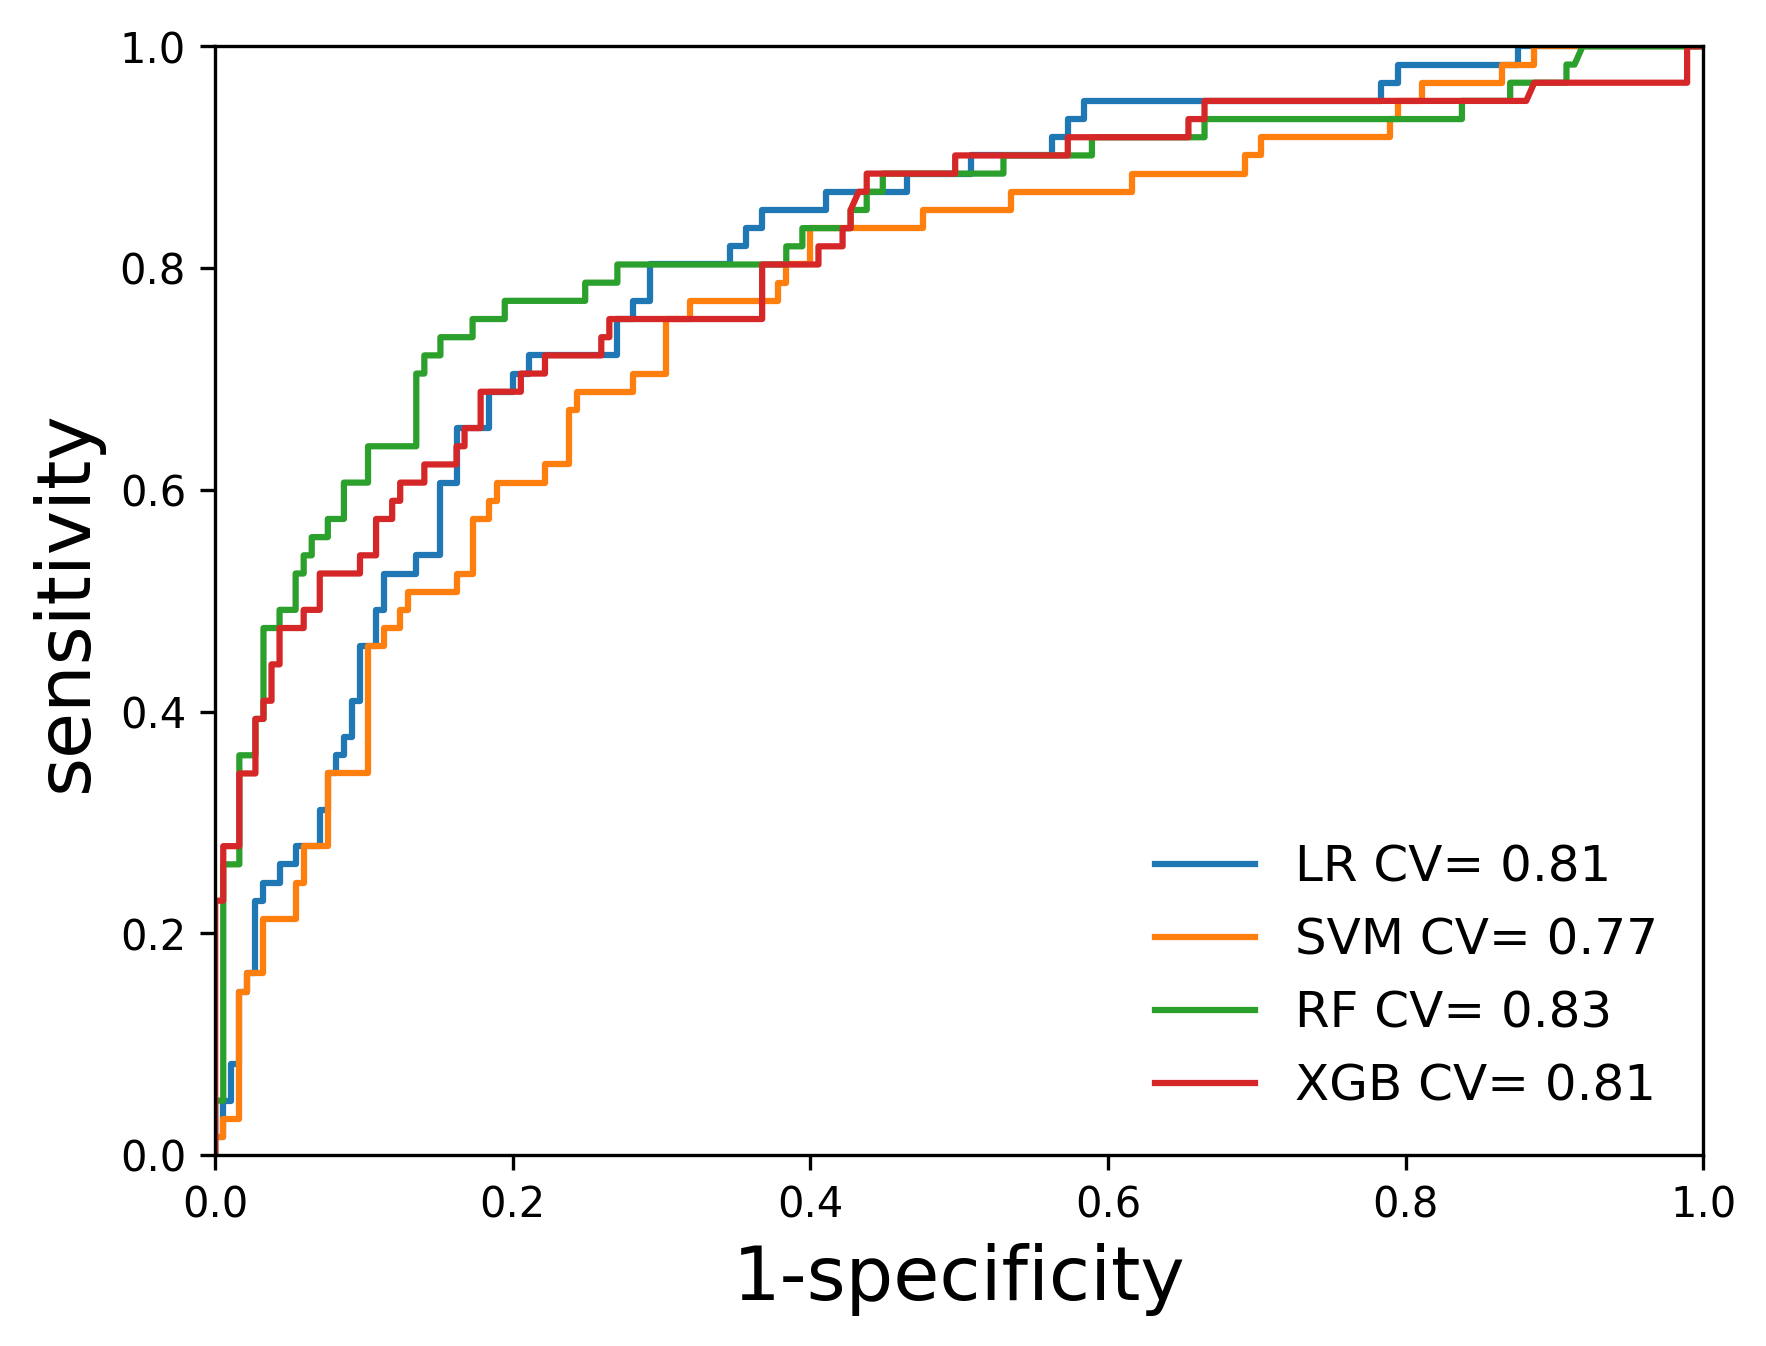

In [21]:
ftr_importances = create_curve(classlist, train_x, train_y, test_x, test_y)
CVROC(classlist,data_x,data_y)